<a href="https://colab.research.google.com/github/salsafadilah/Digital-Image-Detection-PalmOil/blob/main/Digital_Image_Detection_PalmOil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics roboflow

In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="vEHmH7ySdxecdJ2lZ8hd")
project = rf.workspace("trial-g0z45").project("kesehatan-pohon-sawit-vu4sc-5qatc")
version = project.version(3)
dataset = version.download("yolo26")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to KESEHATAN-POHON-SAWIT-3 in yolo26:: 100%|██████████| 289/289 [00:00<00:00, 7105.24it/s]


In [3]:
from ultralytics import YOLO
model = YOLO("yolo26s.pt")
model.train(
    data=f"{dataset.location}/data.yaml",  # Path ke file data.yaml dataset
    epochs=50,                             # Jumlah epochs (atur sesuai kebutuhan)
    batch=16,                              # Ukuran batch
    imgsz=640,                             # Resolusi gambar
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/KESEHATAN-POHON-SAWIT-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c877cbcefc0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804


image 1/1 /content/tile_img_8_3 (1).png: 640x640 35 healthys, 5 unhealthys, 16.8ms
Speed: 1.6ms preprocess, 16.8ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


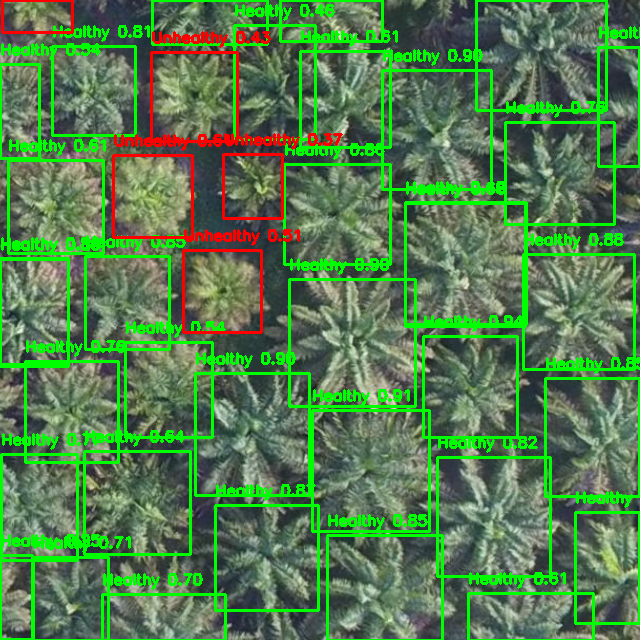

In [4]:
import cv2
from ultralytics import YOLO
from google.colab.patches import cv2_imshow # Gunakan ini jika di Google Colab

# 1. Load model
model = YOLO("/content/runs/detect/train/weights/best.pt")

# 2. Path gambar yang ingin dites
img_path = "/content/tile_img_8_3 (1).png"
image = cv2.imread(img_path)

# 3. Jalankan prediksi (tanpa plotting otomatis)
results = model.predict(source=img_path, conf=0.25)

# 4. Gambar Box Manual
for r in results:
    boxes = r.boxes
    for box in boxes:
        # Ambil koordinat box (x1, y1, x2, y2)
        x1, y1, x2, y2 = box.xyxy[0]
        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)

        # Ambil ID kelas (0 untuk healthy, 1 untuk unhealthy)
        cls = int(box.cls[0])
        conf = float(box.conf[0])

        # Tentukan warna (Format BGR di OpenCV: (Blue, Green, Red))
        # Hijau untuk Healthy (ID 0), Merah untuk Unhealthy (ID 1)
        if cls == 0:
            color = (0, 255, 0) # Hijau
            label = f"Healthy {conf:.2f}"
        else:
            color = (0, 0, 255) # Merah
            label = f"Unhealthy {conf:.2f}"

        # Gambar Bounding Box (Outline saja, thickness=2)
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)

        # Tambahkan Label Teks di atas Box
        cv2.putText(image, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

# 5. Tampilkan Hasil Akhir
cv2_imshow(image)


image 1/1 /content/tile_img_8_5.png: 640x640 34 healthys, 4 unhealthys, 32.9ms
Speed: 6.8ms preprocess, 32.9ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


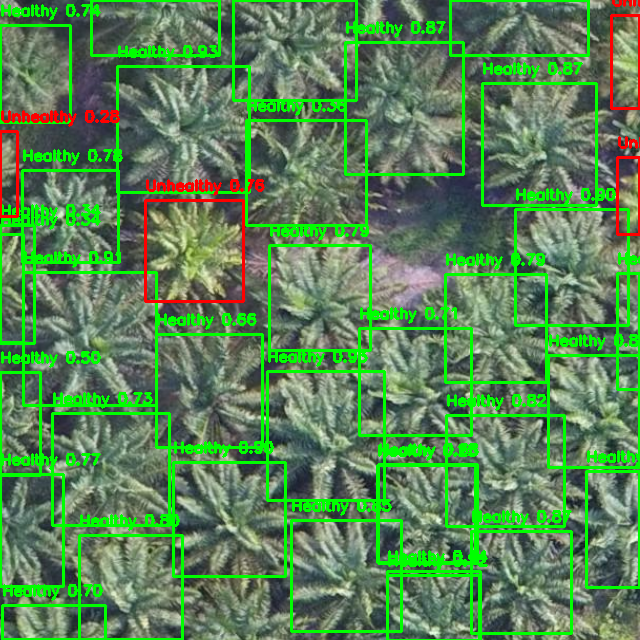

In [5]:
import cv2
from ultralytics import YOLO
from google.colab.patches import cv2_imshow # Gunakan ini jika di Google Colab

# 1. Load model
model = YOLO("/content/runs/detect/train/weights/best.pt")

# 2. Path gambar yang ingin dites
img_path = "/content/tile_img_8_5.png"
image = cv2.imread(img_path)

# 3. Jalankan prediksi (tanpa plotting otomatis)
results = model.predict(source=img_path, conf=0.25)

# 4. Gambar Box Manual
for r in results:
    boxes = r.boxes
    for box in boxes:
        # Ambil koordinat box (x1, y1, x2, y2)
        x1, y1, x2, y2 = box.xyxy[0]
        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)

        # Ambil ID kelas (0 untuk healthy, 1 untuk unhealthy)
        cls = int(box.cls[0])
        conf = float(box.conf[0])

        # Tentukan warna (Format BGR di OpenCV: (Blue, Green, Red))
        # Hijau untuk Healthy (ID 0), Merah untuk Unhealthy (ID 1)
        if cls == 0:
            color = (0, 255, 0) # Hijau
            label = f"Healthy {conf:.2f}"
        else:
            color = (0, 0, 255) # Merah
            label = f"Unhealthy {conf:.2f}"

        # Gambar Bounding Box (Outline saja, thickness=2)
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)

        # Tambahkan Label Teks di atas Box
        cv2.putText(image, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

# 5. Tampilkan Hasil Akhir
cv2_imshow(image)